In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [16]:
path = "../data/diabetic_data.csv"
df = pd.read_csv(path, low_memory=False)

with pd.option_context('display.max_columns', None):
    display(df.head())

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Data Cleaning

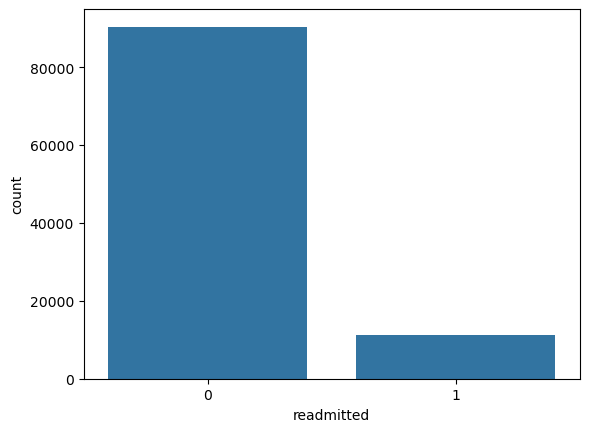

In [17]:
df["readmitted"] = df["readmitted"].map({
    "<30": 1,  # readmitted before 30 days 
    ">30": 0,  # readmitted after 30 days 
    "NO": 0
})

ax = sns.countplot(df, x = 'readmitted')
plt.show()

In [18]:
df.replace('?', np.nan, inplace=True)

na_prop = df.isna().sum() / len(df)
display(na_prop[na_prop > 0].sort_values(ascending = False))

weight               0.968585
max_glu_serum        0.947468
A1Cresult            0.832773
medical_specialty    0.490822
payer_code           0.395574
race                 0.022336
diag_3               0.013983
diag_2               0.003518
diag_1               0.000206
dtype: float64

## Feature Engineering

In [19]:
df['glu_tested'] = ~df['max_glu_serum'].isna()
df['A1C_tested'] = ~df['A1Cresult'].isna()

In [20]:
def match_icd9_group(diag_col):
    #ICD9 codes referring to an external cause begin with a letter E-V. I'll replace all of these with numeric values using regex
    diag_col = diag_col.str.replace(r'[E-V]\d*', '1000', regex = True).astype(float)

    #Matches each condition with its ICD9 grouping
    conditions = [
        (diag_col.between(390, 459)) | (diag_col == 785), #circulatory
        (diag_col.between(460, 519)) | (diag_col == 786), #respiratory
        (diag_col.between(520, 579)) | (diag_col == 787), #digestive
        np.floor(diag_col) == 250, #diabetes
        diag_col.between(800, 999), #injury
        diag_col.between(710, 739), #musculoskeletal
        (diag_col.between(580, 629)) | (diag_col == 788), #genitourinary
        diag_col.between(140, 239), #neoplasms (cancer/other tissue growths)
        diag_col.isna() #na
    ] #anything else is defined as 'other'

    groups = [
        'circulatory', 
        'respiratory', 
        'digestive', 
        'diabetes', 
        'injury', 
        'musculoskeletal',
        'genitourinary',
        'neoplasms',
        'na'
    ]
    
    return pd.Series(np.select(conditions, groups, default = 'other'))

df['diag_1g'] = match_icd9_group(df['diag_1'])
df['diag_2g'] = match_icd9_group(df['diag_2'])
df['diag_3g'] = match_icd9_group(df['diag_3'])
df['diag_1g'].value_counts(normalize = True)

diag_1g
circulatory        0.299088
other              0.178567
respiratory        0.141727
digestive          0.093106
diabetes           0.086050
injury             0.068530
genitourinary      0.050282
musculoskeletal    0.048710
neoplasms          0.033734
na                 0.000206
Name: proportion, dtype: float64

In [21]:
specialty_map = {
    # Internal Medicine
    'InternalMedicine': 'Internal_Medicine', 
    'Nephrology': 'Internal_Medicine',
    'Pulmonology': 'Internal_Medicine',
    'Gastroenterology': 'Internal_Medicine',
    'Cardiology': 'Internal_Medicine',

    # General
    'Family/GeneralPractice': 'General', 
    
    # Emergency
    'Emergency/Trauma': 'Emergency',
    
    # Surgery
    'Surgery-Cardiovascular/Thoracic': 'Surgery',
    'Surgery-General': 'Surgery', 
    'Orthopedics': 'Surgery',
    'Surgery-Vascular': 'Surgery', 
    'Urology': 'Surgery',
    'Orthopedics-Reconstructive': 'Surgery',
    
    # Pysch
    'Psychiatry': 'Pysch', 
 
    # Reproductive Health
    'ObstetricsandGynecology': 'OB-GYN', 

    # Diagnosis
    'Radiologist': 'Diagnosis',
    
    #other
    'Other': 'Other',
}

df['specialty_grouped'] = df['medical_specialty'].map(specialty_map).fillna('Unknown')
#df.drop('medical_specialty', axis=1, inplace=True)

In [22]:
df['total_visits'] = df['number_inpatient'] + df['number_outpatient'] + df['number_emergency']

fig = px.histogram(df, color = 'readmitted', x = 'total_visits', barmode = 'overlay', log_y = True)
fig.show()

## Splitting Data

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X = df.drop(columns = ["encounter_id", "patient_nbr", "weight", "max_glu_serum", "A1Cresult", "diag_1", "diag_2", "diag_3", "readmitted"])
y = df["readmitted"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=631, stratify=y)

## Pipelines

In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from sklearn.feature_selection import VarianceThreshold
from imblearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown = 'ignore'))
])

prep = ColumnTransformer([
    ('number', numeric_transformer, make_column_selector(dtype_include='number')),
    ('category', categorical_transformer, make_column_selector(dtype_include='object'))
], remainder = 'passthrough')

clf_pipeline = Pipeline([
    ('preprocess', prep),
    ('oversample', RandomUnderSampler()),
    ('selection', VarianceThreshold()),
    ('clf', DecisionTreeClassifier())
])

clf_pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('number',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x00000144BBA5C9D0>),
                                                 ('category',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x00000144BBA5CC90>)])),
                ('oversample', RandomUnderSampler()),
                ('selection', VarianceThreshold()),
                ('clf', DecisionTreeClassifier())])

In [49]:
pd.concat([X_train.dtypes, X_train.nunique()], axis = 1)

,0,1
race,object,5
gender,object,3
age,object,10
admission_type_id,int64,8
discharge_disposition_id,int64,26
admission_source_id,int64,17
time_in_hospital,int64,14
payer_code,object,17
medical_specialty,object,72
num_lab_procedures,int64,118


In [54]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

param_grid = [
    {
        'clf': [LogisticRegression(max_iter = 500)]
    }, 
    {
        'clf': [DecisionTreeClassifier()],
        'clf__splitter': ['best', 'random'],
        'clf__max_depth': [None, 10]
    },
    {
        'clf': [KNeighborsClassifier()],
        'clf__n_neighbors': [3, 5, 7],
        'clf__weights': ['uniform', 'distance']
    },
    {
        'clf': [RandomForestClassifier()],
        'clf__n_estimators': [50, 100],
        'clf__max_depth': [None, 10],
        'clf__max_features': ['sqrt', 'log2', None]
    },
    {
        'clf': [AdaBoostClassifier()],
        'clf__n_estimators': [50, 100],
        'clf__learning_rate': [0.5, 1.0, 2.0]
    }
]

grid = GridSearchCV(clf_pipeline, param_grid, cv = 5, scoring = scoring, refit = 'f1')
grid.fit(X_train, y_train)

scores = pd.DataFrame(grid.cv_results_)
display(scores.head())

scores.to_csv('../data/cv_scores.csv', index = False)

KeyboardInterrupt: 

81412